In [1]:
from PIL import Image
import numpy as np
from torchvision.transforms.functional import to_tensor
from pathlib import Path

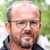

In [2]:
new_size = 50

im_rgb = Image.open('images/waldek1.jpg').resize((new_size, new_size))
im_rgb

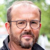

In [5]:
arr_rgb = (np.array(im_rgb)/255*100).astype(int)

Image.fromarray(((arr_rgb / 100)*255).astype(np.uint8))

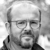

In [6]:
im_gray = im_rgb.convert('L')
im_gray

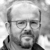

In [7]:
arr_gray = (np.array(im_gray)/255*100).astype(int)

Image.fromarray(((arr_gray / 100)*255).astype(np.uint8))

In [8]:
def save_channel(arr, name, subdir):
    lines = []
    lines.append(f'const {name} = [')

    for row in arr:
        lines.append(' '*4 + '[' + r', '.join(fr'{x}' for x in row) + '],')
    lines.append('];')

    lines.append('')
    lines.append(f'export default {name};')

    text = '\n'.join(lines)
    Path(f'../animations/{subdir}/{name}.js').write_text(text)

In [10]:
arr_rgb.shape

(50, 50, 3)

In [11]:
save_channel(arr_gray, 'waldek_the_gray', 'image_palette')
save_channel(arr_rgb[..., 0], 'waldek_the_red', 'image_palette_rgb')
save_channel(arr_rgb[..., 1], 'waldek_the_green', 'image_palette_rgb')
save_channel(arr_rgb[..., 2], 'waldek_the_blue', 'image_palette_rgb')